# Upshot
Model: A system of N modes on which we refresh one mode sequentially during each timestep. Now there are cross kerr interactions between among the modes \(\chi_{ij}\). So for instance, during each timestep, the 0th mode feels a "phase kicks" due to the occupation in other modes \(n_{j}\)
$$\delta \phi = \phi_1 + \phi_2 + ... + \phi_N = \sum_{j = 1}^N \chi_{0j} n_j$$

## Basic Simulation
Start with t =0 where all modes are empty and take T timesteps. We will track the total phase of the 0th mode \(\Phi(t)\). 
At each timestep say t = k: 
- Update the population of  (k mod N)'th mode \(n \in (0,1) \) whcih is normally distributed around mean of 1/2 
- If k mod N = 0 , then do nothing. (later we will simulate effect of Hahn echoes here). 
- Compute the net phase kick due to occupations in all N-1 modes and add it to the total phase of 0th mode. 

## Monte Carlo Method
Do multiple rounds of this M step simulation. 

## The Dephasing 
I want to plot the net dephasing \(\expval{e^{i\phi(t)}}\) as a function of timesteps and number of modes

In [40]:
import numpy as np
import matplotlib.pyplot as plt

class CrossKerrSimulator:
    def __init__(self, n_modes, chi_val=0.05):
        """
        Initializes the system parameters.
        """
        self.n_modes = n_modes
        # Interaction vector: 0th mode interacting with mode j
        self.chi = np.full(n_modes, chi_val)
        self.chi[0] = 0  # 0th mode doesn't give itself a kick
        
    def _get_random_population(self):
        """Generates a population value normally distributed around 0.5."""
        return np.random.normal(loc=0.5, scale=0.1)

    def run_single_trial(self, t_steps):
        """
        Simulates one realization of the phase evolution.
        """
        populations = np.zeros(self.n_modes)
        phase_history = np.zeros(t_steps)
        current_phase = 0.0
        
        for k in range(1, t_steps):
            mode_to_update = k % self.n_modes
            
            # Update population
            if mode_to_update !=0: 
                populations[mode_to_update] = self._get_random_population()
            
            # Phase calculation logic
            kick = np.sum(self.chi * populations)
            current_phase += kick
            
            phase_history[k] = current_phase
            
        return phase_history

    def simulate_dephasing(self, t_steps, m_trials):
        """
        Runs Monte Carlo trials and computes the ensemble average <e^iφ>.
        """
        all_trials = np.array([self.run_single_trial(t_steps) for _ in range(m_trials)])
        
        # Compute <exp(i * phi)>
        complex_phasors = np.exp(1j * all_trials)
        ensemble_average = np.mean(complex_phasors, axis=0)
        
        return np.abs(ensemble_average)





## Checking if logic of simulation makes sense

In [41]:
accumulated_cross_kerr_per_timestep_per_mode = 0.001#1 khz * 1 mus 
sim = CrossKerrSimulator(n_modes=10, chi_val=accumulated_cross_kerr_per_timestep_per_mode)
sim.simulate_dephasing(t_steps=10, m_trials=200)



array([1.        , 1.        , 0.99999998, 0.99999993, 0.99999985,
       0.99999972, 0.99999952, 0.99999923, 0.99999884, 0.99999832])

# Iterating over number of timesteps

In [44]:
def plot_results(results_dict, t_steps):
    """
    Handles the visualization of dephasing curves.
    """
    plt.figure(figsize=(10, 6))
    for label, coherence in results_dict.items():
        plt.plot(coherence, label=label)
        
    plt.title(r'Cross-Kerr Dephasing $\langle e^{i\Phi(t)} \rangle$')
    plt.xlabel('Timestep (k)')
    plt.ylabel('Coherence Persistence')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    # plt.ylim(0, 1.05)
    plt.yscale('log')
    plt.show()

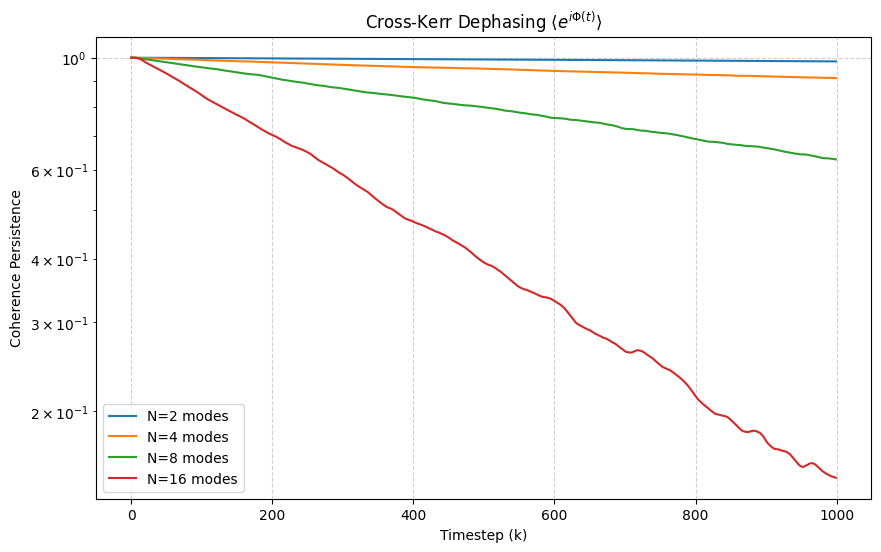

In [45]:
T_STEPS = 1000
M_TRIALS = 1500
MODES_TO_TEST = [2, 4, 8, 16]

simulation_results = {}

for n in MODES_TO_TEST:
    sim = CrossKerrSimulator(n_modes=n, chi_val=0.04)
    coherence_curve = sim.simulate_dephasing(T_STEPS, M_TRIALS)
    simulation_results[f"N={n} modes"] = coherence_curve
    
plot_results(simulation_results, T_STEPS)

## Iteration over number of modes 

In [63]:
accumulated_cross_kerr_per_timestep_per_mode = 0.0001#100 hz * 1 mus 

In [64]:
T_STEPS = 1000
M_TRIALS = 1500
MODES_TO_TEST = [2, 4, 8, 16, 32, 64, 100]

simulation_results = {}

for n in MODES_TO_TEST:
    sim = CrossKerrSimulator(n_modes=n, chi_val=accumulated_cross_kerr_per_timestep_per_mode)
    coherence_curve = sim.simulate_dephasing(T_STEPS, M_TRIALS)
    simulation_results[f"N={n} modes"] = coherence_curve
    


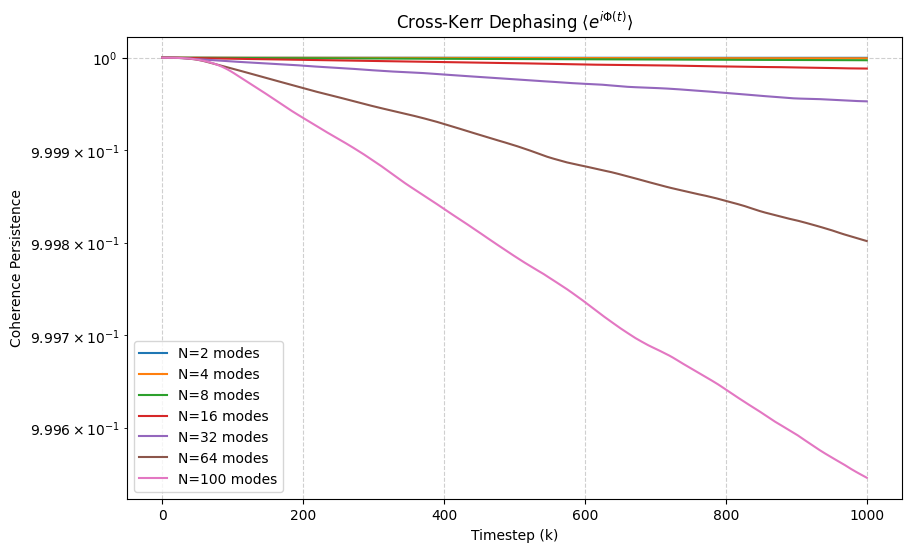

In [65]:
plot_results(simulation_results, T_STEPS)

In [52]:
simulation_results.keys()   

dict_keys(['N=2 modes', 'N=4 modes', 'N=8 modes', 'N=16 modes', 'N=32 modes', 'N=64 modes', 'N=100 modes'])

In [66]:
def plot_results_as_func_of_modes(simulation_results, T_STEPS = 150, MODES_TO_TEST = []):
    coherence_vs_modes = [simulation_results[f"N={n} modes"][T_STEPS-1] for n in MODES_TO_TEST]
    plt.figure(figsize=(8, 5))
    plt.plot(MODES_TO_TEST, coherence_vs_modes, marker='o')
    # plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Number of Modes (log scale)')
    plt.title(f'Coherence at T={T_STEPS} vs Number of Modes')
    plt.ylabel(r'Coherence $\langle e^{i\Phi(T)} \rangle$ at T={T_STEPS}')
    plt.grid(True, which="both", ls="--", alpha=0.6)
    plt.show()
    ##plt.ylabel(r'Coherence $\langle e^{i\Phi(T)} \r$\langle e^{i\Phi(T)} \rangle$ at T={T_STEPS}')
    

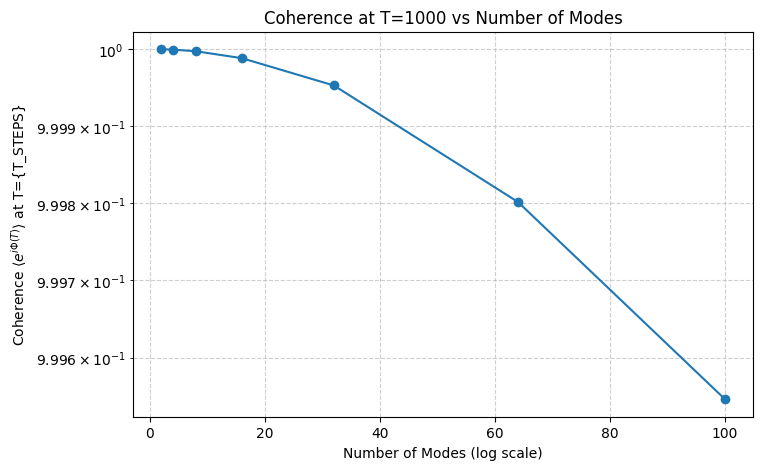

In [67]:
plot_results_as_func_of_modes(simulation_results, T_STEPS = 1000, MODES_TO_TEST = MODES_TO_TEST)